# CREDIT RISK ANALYSIS

## Data Loading

In [1]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [118]:
import warnings
warnings.filterwarnings("ignore")

In [22]:
#Read Data
app_data = pd.read_csv(r"C:\Users\kriti\EDA Credit Case Study\application_data.csv")
prev_data = pd.read_csv(r"C:\Users\kriti\EDA Credit Case Study\previous_application.csv")


In [14]:
app_data.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
app_data.dtypes

SK_ID_CURR                      int64
TARGET                          int64
NAME_CONTRACT_TYPE             object
CODE_GENDER                    object
FLAG_OWN_CAR                   object
                               ...   
AMT_REQ_CREDIT_BUREAU_DAY     float64
AMT_REQ_CREDIT_BUREAU_WEEK    float64
AMT_REQ_CREDIT_BUREAU_MON     float64
AMT_REQ_CREDIT_BUREAU_QRT     float64
AMT_REQ_CREDIT_BUREAU_YEAR    float64
Length: 122, dtype: object

In [6]:
prev_data.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
app_data.shape

(307511, 122)

In [8]:
prev_data.shape

(1670214, 37)

In [25]:
df = app_data.merge(prev_data, on = 'SK_ID_CURR', how = 'inner')

In [26]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE_x,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT_x,AMT_ANNUITY_x,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,Auto technology,24.0,low_normal,POS other with interest,365243.0,-565.0,125.0,-25.0,-17.0,0.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,XNA,12.0,low_normal,Cash X-Sell: low,365243.0,-716.0,-386.0,-536.0,-527.0,1.0
2,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,Furniture,6.0,middle,POS industry with interest,365243.0,-797.0,-647.0,-647.0,-639.0,0.0
3,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,Consumer electronics,12.0,middle,POS household with interest,365243.0,-2310.0,-1980.0,-1980.0,-1976.0,1.0
4,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,Connectivity,4.0,middle,POS mobile without interest,365243.0,-784.0,-694.0,-724.0,-714.0,0.0


In [32]:
df.shape

(1413701, 138)

In [49]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE_x,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT_x,AMT_ANNUITY_x,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,Auto technology,24.0,low_normal,POS other with interest,365243.0,-565.0,125.0,-25.0,-17.0,0.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,XNA,12.0,low_normal,Cash X-Sell: low,365243.0,-716.0,-386.0,-536.0,-527.0,1.0
2,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,Furniture,6.0,middle,POS industry with interest,365243.0,-797.0,-647.0,-647.0,-639.0,0.0
3,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,Consumer electronics,12.0,middle,POS household with interest,365243.0,-2310.0,-1980.0,-1980.0,-1976.0,1.0
4,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,Connectivity,4.0,middle,POS mobile without interest,365243.0,-784.0,-694.0,-724.0,-714.0,0.0


## Data Cleaning

First drop un-unecessary columns
Then check percentage of null values in each columns, and drop columns that have null values >30% 

In [28]:
#drop un-necessary Columns
columns_to_drop = ['FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4','FLAG_DOCUMENT_5','FLAG_DOCUMENT_6','FLAG_DOCUMENT_7','FLAG_DOCUMENT_8','FLAG_DOCUMENT_9','FLAG_DOCUMENT_10','FLAG_DOCUMENT_11','FLAG_DOCUMENT_12','FLAG_DOCUMENT_13','FLAG_DOCUMENT_14','FLAG_DOCUMENT_15','FLAG_DOCUMENT_16','FLAG_DOCUMENT_17','FLAG_DOCUMENT_18','FLAG_DOCUMENT_19','FLAG_DOCUMENT_20','FLAG_DOCUMENT_21']

In [31]:
df = df.drop(columns= columns_to_drop)

In [44]:
#checking null values percentage in below columns
df[['BASEMENTAREA_AVG','APARTMENTS_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'TOTALAREA_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']].isnull().mean()*100

BASEMENTAREA_AVG                58.308511
APARTMENTS_AVG                  50.364115
YEARS_BEGINEXPLUATATION_AVG     48.431882
YEARS_BUILD_AVG                 66.298107
COMMONAREA_AVG                  69.689347
ELEVATORS_AVG                   52.996779
ENTRANCES_AVG                   49.995155
FLOORSMAX_AVG                   49.409882
FLOORSMIN_AVG                   67.670604
LANDAREA_AVG                    59.218533
LIVINGAPARTMENTS_AVG            68.214566
LIVINGAREA_AVG                  49.826661
NONLIVINGAPARTMENTS_AVG         69.296549
NONLIVINGAREA_AVG               54.860115
APARTMENTS_MODE                 50.364115
BASEMENTAREA_MODE               58.308511
YEARS_BEGINEXPLUATATION_MODE    48.431882
YEARS_BUILD_MODE                66.298107
COMMONAREA_MODE                 69.689347
ELEVATORS_MODE                  52.996779
ENTRANCES_MODE                  49.995155
FLOORSMAX_MODE                  49.409882
FLOORSMIN_MODE                  67.670604
LANDAREA_MODE                   59

In [45]:
#dropping columns based on precentage of null values
columns_to_drop2 = ['BASEMENTAREA_AVG','APARTMENTS_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'TOTALAREA_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']
df = df.drop(columns= columns_to_drop2)

In [89]:
df.shape

(1413701, 68)

In [51]:
#checking null values percentage in below columns
df[['TARGET', 'NAME_CONTRACT_TYPE_x', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT_x', 'AMT_ANNUITY_x', 'AMT_GOODS_PRICE_x', 'NAME_TYPE_SUITE_x', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START_x', 'HOUR_APPR_PROCESS_START_x', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].isnull().mean()*100

TARGET                           0.000000
NAME_CONTRACT_TYPE_x             0.000000
CODE_GENDER                      0.000000
FLAG_OWN_CAR                     0.000000
FLAG_OWN_REALTY                  0.000000
CNT_CHILDREN                     0.000000
AMT_INCOME_TOTAL                 0.000000
AMT_CREDIT_x                     0.000000
AMT_ANNUITY_x                    0.006578
AMT_GOODS_PRICE_x                0.085449
NAME_TYPE_SUITE_x                0.249416
NAME_INCOME_TYPE                 0.000000
NAME_EDUCATION_TYPE              0.000000
NAME_FAMILY_STATUS               0.000000
NAME_HOUSING_TYPE                0.000000
REGION_POPULATION_RELATIVE       0.000000
DAYS_BIRTH                       0.000000
DAYS_EMPLOYED                    0.000000
DAYS_REGISTRATION                0.000000
DAYS_ID_PUBLISH                  0.000000
OWN_CAR_AGE                     66.294499
FLAG_MOBIL                       0.000000
FLAG_EMP_PHONE                   0.000000
FLAG_WORK_PHONE                  0

In [77]:
#checking correlation of various variables with respect to 'TARGET' variable
df['TARGET'].corr(df['AMT_REQ_CREDIT_BUREAU_YEAR'])

np.float64(0.016432053765191766)

In [60]:
#dropping columns based on precentage of null values and low correlation values
columns_to_drop3 = ['OWN_CAR_AGE', 'EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']
df = df.drop(columns= columns_to_drop3)

In [64]:
##checking null values percentage in below columns
df[['OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'DAYS_LAST_PHONE_CHANGE']].isnull().mean()*100

OBS_30_CNT_SOCIAL_CIRCLE    0.222536
DEF_30_CNT_SOCIAL_CIRCLE    0.222536
OBS_60_CNT_SOCIAL_CIRCLE    0.222536
DEF_60_CNT_SOCIAL_CIRCLE    0.222536
DAYS_LAST_PHONE_CHANGE      0.000000
dtype: float64

In [71]:
#checking null values percentage in below columns
df[['AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR']].isnull().mean()*100 

AMT_REQ_CREDIT_BUREAU_HOUR    11.574371
AMT_REQ_CREDIT_BUREAU_DAY     11.574371
AMT_REQ_CREDIT_BUREAU_WEEK    11.574371
AMT_REQ_CREDIT_BUREAU_MON     11.574371
AMT_REQ_CREDIT_BUREAU_QRT     11.574371
AMT_REQ_CREDIT_BUREAU_YEAR    11.574371
dtype: float64

In [79]:
#dropping columns based on precentage of null values and low correlation values
columns_to_drop4 = ['AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR']
df = df.drop(columns= columns_to_drop4)

In [99]:
pd.set_option('display.max_rows', None)  # Show all rows
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)  # Use full width of the screen
pd.set_option('display.max_colwidth', None)

In [83]:
prev_data.isna().mean()*100

SK_ID_PREV                      0.000000
SK_ID_CURR                      0.000000
NAME_CONTRACT_TYPE              0.000000
AMT_ANNUITY                    22.286665
AMT_APPLICATION                 0.000000
AMT_CREDIT                      0.000060
AMT_DOWN_PAYMENT               53.636480
AMT_GOODS_PRICE                23.081773
WEEKDAY_APPR_PROCESS_START      0.000000
HOUR_APPR_PROCESS_START         0.000000
FLAG_LAST_APPL_PER_CONTRACT     0.000000
NFLAG_LAST_APPL_IN_DAY          0.000000
RATE_DOWN_PAYMENT              53.636480
RATE_INTEREST_PRIMARY          99.643698
RATE_INTEREST_PRIVILEGED       99.643698
NAME_CASH_LOAN_PURPOSE          0.000000
NAME_CONTRACT_STATUS            0.000000
DAYS_DECISION                   0.000000
NAME_PAYMENT_TYPE               0.000000
CODE_REJECT_REASON              0.000000
NAME_TYPE_SUITE                49.119754
NAME_CLIENT_TYPE                0.000000
NAME_GOODS_CATEGORY             0.000000
NAME_PORTFOLIO                  0.000000
NAME_PRODUCT_TYP

In [84]:
#dropping columns based on precentage of null values and low correlation values
columns_to_drop5 = ['DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION', 'DAYS_LAST_DUE', 'DAYS_TERMINATION', 'NFLAG_INSURED_ON_APPROVAL']
df = df.drop(columns= columns_to_drop5)

In [125]:
#dropping columns based on precentage of null values and low correlation values
columns_to_drop6 = ['NAME_TYPE_SUITE_x', 'RATE_DOWN_PAYMENT', 'RATE_INTEREST_PRIMARY', 'RATE_INTEREST_PRIVILEGED', 'AMT_DOWN_PAYMENT', 'AMT_ANNUITY_x','AMT_GOODS_PRICE_x']
df = df.drop(columns= columns_to_drop6)
df = df.drop(columns= 'CNT_PAYMENT')
df = df.drop(columns = 'AMT_CREDIT_y')

Filling the null values for remaining columns. 
CATEGORICAL column - use Mode
NUMERICAL column - use mean or median 

In [133]:
#percentage of null vlaues in merged dataset df
df.isna().mean()*100

SK_ID_CURR                      0.0
TARGET                          0.0
NAME_CONTRACT_TYPE_x            0.0
CODE_GENDER                     0.0
FLAG_OWN_CAR                    0.0
FLAG_OWN_REALTY                 0.0
CNT_CHILDREN                    0.0
AMT_INCOME_TOTAL                0.0
AMT_CREDIT_x                    0.0
NAME_INCOME_TYPE                0.0
NAME_EDUCATION_TYPE             0.0
NAME_FAMILY_STATUS              0.0
NAME_HOUSING_TYPE               0.0
REGION_POPULATION_RELATIVE      0.0
DAYS_BIRTH                      0.0
DAYS_EMPLOYED                   0.0
DAYS_REGISTRATION               0.0
DAYS_ID_PUBLISH                 0.0
FLAG_MOBIL                      0.0
FLAG_EMP_PHONE                  0.0
FLAG_WORK_PHONE                 0.0
FLAG_CONT_MOBILE                0.0
FLAG_PHONE                      0.0
FLAG_EMAIL                      0.0
OCCUPATION_TYPE                 0.0
CNT_FAM_MEMBERS                 0.0
REGION_RATING_CLIENT            0.0
REGION_RATING_CLIENT_W_CITY 

In [105]:
print(df['OCCUPATION_TYPE'].value_counts(normalize = True))

OCCUPATION_TYPE
Laborers                 0.262832
Sales staff              0.158304
Core staff               0.123700
Managers                 0.099298
Drivers                  0.087925
High skill tech staff    0.050708
Accountants              0.043884
Medicine staff           0.041835
Security staff           0.033157
Cooking staff            0.030044
Cleaning staff           0.025444
Private service staff    0.012800
Low-skill Laborers       0.009748
Waiters/barmen staff     0.006413
Secretaries              0.006001
Realty agents            0.003707
HR staff                 0.002419
IT staff                 0.001781
Name: proportion, dtype: float64


In [104]:
occup_mode = df.OCCUPATION_TYPE.mode()[0]
occup_mode

'Laborers'

In [127]:
#checking TARGET values for different values of OCCUPATION_TYPE
df.groupby(['OCCUPATION_TYPE', 'TARGET'])['TARGET'].count()/df.groupby('OCCUPATION_TYPE')['TARGET'].count()*100

OCCUPATION_TYPE        TARGET
Accountants            0         94.260928
                       1          5.739072
Cleaning staff         0         90.751398
                       1          9.248602
Cooking staff          0         89.065655
                       1         10.934345
Core staff             0         93.152225
                       1          6.847775
Drivers                0         87.956035
                       1         12.043965
HR staff               0         92.650238
                       1          7.349762
High skill tech staff  0         93.020234
                       1          6.979766
IT staff               0         93.129771
                       1          6.870229
Laborers               0         91.531418
                       1          8.468582
Low-skill Laborers     0         80.901288
                       1         19.098712
Managers               0         92.869256
                       1          7.130744
Medicine staff         0

In [109]:
#fill missing values using central tendency -> mode for OCCUPATION_TYPE
df['OCCUPATION_TYPE'].fillna(occup_mode, inplace=True)

In [111]:
df.OCCUPATION_TYPE.isnull().sum()

np.int64(0)

In [115]:
print(df['TARGET'].corr(df['OBS_30_CNT_SOCIAL_CIRCLE']))
print(df['TARGET'].corr(df['DEF_30_CNT_SOCIAL_CIRCLE']))
print(df['TARGET'].corr(df['OBS_60_CNT_SOCIAL_CIRCLE']))
print(df['TARGET'].corr(df['DEF_60_CNT_SOCIAL_CIRCLE']))

0.014000922984481103
0.031870477047066345
0.013877601433274468
0.028527040846877585


In [119]:
#filling null values in above columns with median
df["OBS_30_CNT_SOCIAL_CIRCLE"].fillna(df["OBS_30_CNT_SOCIAL_CIRCLE"].median(), inplace=True)
df["DEF_30_CNT_SOCIAL_CIRCLE"].fillna(df["DEF_30_CNT_SOCIAL_CIRCLE"].median(), inplace=True)
df["OBS_60_CNT_SOCIAL_CIRCLE"].fillna(df["OBS_60_CNT_SOCIAL_CIRCLE"].median(), inplace=True)
df["DEF_60_CNT_SOCIAL_CIRCLE"].fillna(df["DEF_60_CNT_SOCIAL_CIRCLE"].median(), inplace=True)

In [129]:
print(df['PRODUCT_COMBINATION'].value_counts(normalize = True))

PRODUCT_COMBINATION
Cash                              0.166339
POS household with interest       0.160228
POS mobile with interest          0.135030
Cash X-Sell: middle               0.084928
Cash X-Sell: low                  0.078251
Card Street                       0.066927
POS industry with interest        0.059084
POS household without interest    0.050601
Card X-Sell                       0.047244
Cash Street: high                 0.036578
Cash X-Sell: high                 0.035943
Cash Street: middle               0.021179
Cash Street: low                  0.020230
POS other with interest           0.014369
POS mobile without interest       0.014073
POS industry without interest     0.007515
POS others without interest       0.001482
Name: proportion, dtype: float64


In [130]:
product_comb_mode = df.PRODUCT_COMBINATION.mode()[0]
product_comb_mode

'Cash'

In [131]:
#fill missing values using central tendency -> mode for PRODUCT_COMBINATION
df['PRODUCT_COMBINATION'].fillna(occup_mode, inplace=True)

In [139]:
df.PRODUCT_COMBINATION.isnull().sum()

np.int64(0)

## Data Analysis - Univariate

In [128]:
df.shape

(1413701, 63)

In [140]:
df.dtypes

SK_ID_CURR                        int64
TARGET                            int64
NAME_CONTRACT_TYPE_x             object
CODE_GENDER                      object
FLAG_OWN_CAR                     object
FLAG_OWN_REALTY                  object
CNT_CHILDREN                      int64
AMT_INCOME_TOTAL                float64
AMT_CREDIT_x                    float64
NAME_INCOME_TYPE                 object
NAME_EDUCATION_TYPE              object
NAME_FAMILY_STATUS               object
NAME_HOUSING_TYPE                object
REGION_POPULATION_RELATIVE      float64
DAYS_BIRTH                        int64
DAYS_EMPLOYED                     int64
DAYS_REGISTRATION               float64
DAYS_ID_PUBLISH                   int64
FLAG_MOBIL                        int64
FLAG_EMP_PHONE                    int64
FLAG_WORK_PHONE                   int64
FLAG_CONT_MOBILE                  int64
FLAG_PHONE                        int64
FLAG_EMAIL                        int64
OCCUPATION_TYPE                  object


In [134]:
df.head(5)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE_x,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT_x,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START_x,HOUR_APPR_PROCESS_START_x,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,SK_ID_PREV,NAME_CONTRACT_TYPE_y,AMT_APPLICATION,WEEKDAY_APPR_PROCESS_START_y,HOUR_APPR_PROCESS_START_y,FLAG_LAST_APPL_PER_CONTRACT,NFLAG_LAST_APPL_IN_DAY,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,NAME_YIELD_GROUP,PRODUCT_COMBINATION
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,2.0,2.0,2.0,2.0,-1134.0,1038818,Consumer loans,179055.0,SATURDAY,9,Y,1,XAP,Approved,-606,XNA,XAP,New,Vehicles,POS,XNA,Stone,500,Auto technology,low_normal,POS other with interest
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,1.0,0.0,1.0,0.0,-828.0,1810518,Cash loans,900000.0,FRIDAY,12,Y,1,XNA,Approved,-746,XNA,XAP,Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,low_normal,Cash X-Sell: low
2,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,1.0,0.0,1.0,0.0,-828.0,2636178,Consumer loans,337500.0,SUNDAY,17,Y,1,XAP,Approved,-828,Cash through the bank,XAP,Refreshed,Furniture,POS,XNA,Stone,1400,Furniture,middle,POS industry with interest
3,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,1.0,0.0,1.0,0.0,-828.0,2396755,Consumer loans,68809.5,SATURDAY,15,Y,1,XAP,Approved,-2341,Cash through the bank,XAP,Refreshed,Consumer Electronics,POS,XNA,Country-wide,200,Consumer electronics,middle,POS household with interest
4,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,0.0,0.0,0.0,0.0,-815.0,1564014,Consumer loans,24282.0,FRIDAY,5,Y,1,XAP,Approved,-815,Cash through the bank,XAP,New,Mobile,POS,XNA,Regional / Local,30,Connectivity,middle,POS mobile without interest


In [144]:
# Calculate correlation of all numeric columns with TARGET

numeric_col = df.select_dtypes(exclude=['object']).columns.tolist()
corr_target = df[numeric_col].corr()['TARGET'].sort_values(ascending=False)
print(corr_target)

TARGET                         1.000000
DAYS_BIRTH                     0.074866
DAYS_LAST_PHONE_CHANGE         0.059721
REGION_RATING_CLIENT_W_CITY    0.059700
REGION_RATING_CLIENT           0.056932
DAYS_ID_PUBLISH                0.051037
REG_CITY_NOT_WORK_CITY         0.049353
FLAG_EMP_PHONE                 0.048750
DAYS_REGISTRATION              0.043123
REG_CITY_NOT_LIVE_CITY         0.040681
DAYS_DECISION                  0.039901
LIVE_CITY_NOT_WORK_CITY        0.032757
DEF_30_CNT_SOCIAL_CIRCLE       0.031950
DEF_60_CNT_SOCIAL_CIRCLE       0.028596
FLAG_WORK_PHONE                0.028261
CNT_CHILDREN                   0.020313
CNT_FAM_MEMBERS                0.014847
OBS_30_CNT_SOCIAL_CIRCLE       0.014179
OBS_60_CNT_SOCIAL_CIRCLE       0.014055
REG_REGION_NOT_WORK_REGION     0.006862
LIVE_REGION_NOT_WORK_REGION    0.004159
REG_REGION_NOT_LIVE_REGION     0.003011
FLAG_EMAIL                     0.002063
SK_ID_PREV                     0.002009
FLAG_CONT_MOBILE              -0.000059


In [200]:
df["NAME_CONTRACT_TYPE_x"].value_counts(normalize = True)

NAME_CONTRACT_TYPE_x
Cash loans         0.924605
Revolving loans    0.075395
Name: proportion, dtype: float64

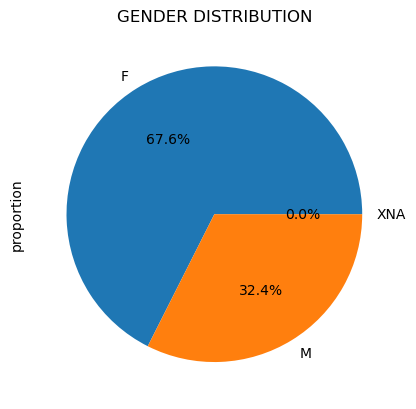

In [196]:
#Uni-variate analysis for CODE_GENDER variable
df["CODE_GENDER"].value_counts(normalize = True).plot.pie(autopct = "%0.1f%%")
plt.title("GENDER DISTRIBUTION")
plt.show()

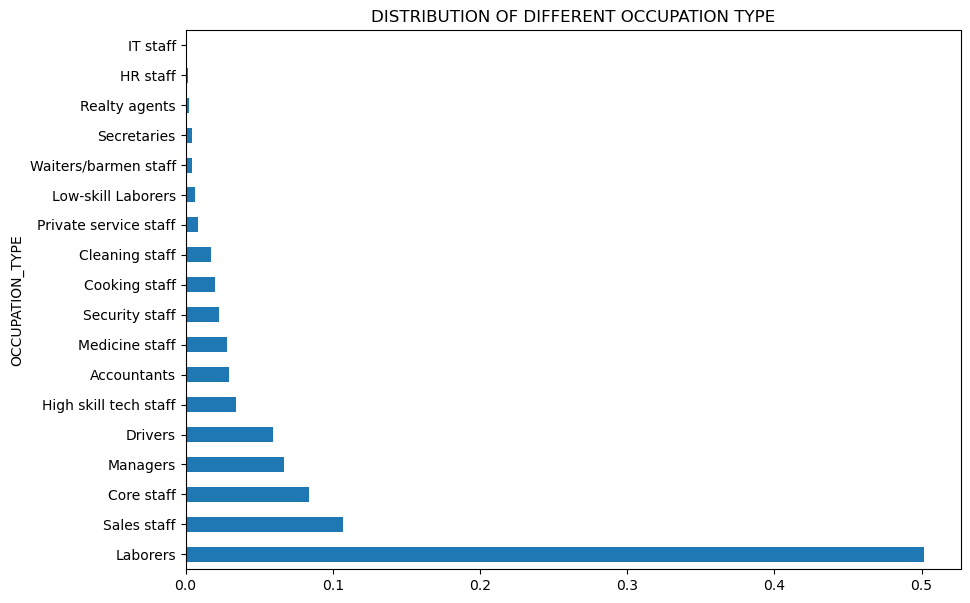

In [219]:
#Uni-variate analysis for OCCUPATION_TYPE 
plt.figure(figsize=(10,7))
df["OCCUPATION_TYPE"].value_counts(normalize = True).plot.barh()
plt.title("DISTRIBUTION OF DIFFERENT OCCUPATION TYPE")
plt.show()

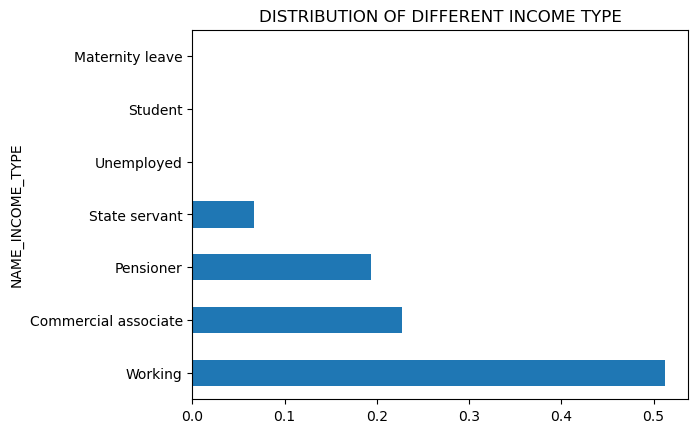

In [221]:
#Uni-variate analysis for INCOME_TYPE
df["NAME_INCOME_TYPE"].value_counts(normalize = True).plot.barh()
plt.title("DISTRIBUTION OF DIFFERENT INCOME TYPE")
plt.show()

In [284]:
#Uni-variate analysis for EDUCATION_TYPE
df["NAME_EDUCATION_TYPE"].value_counts(normalize = True)

NAME_EDUCATION_TYPE
Secondary / secondary special    0.734174
Higher education                 0.221295
Incomplete higher                0.031981
Lower secondary                  0.012141
Academic degree                  0.000410
Name: proportion, dtype: float64

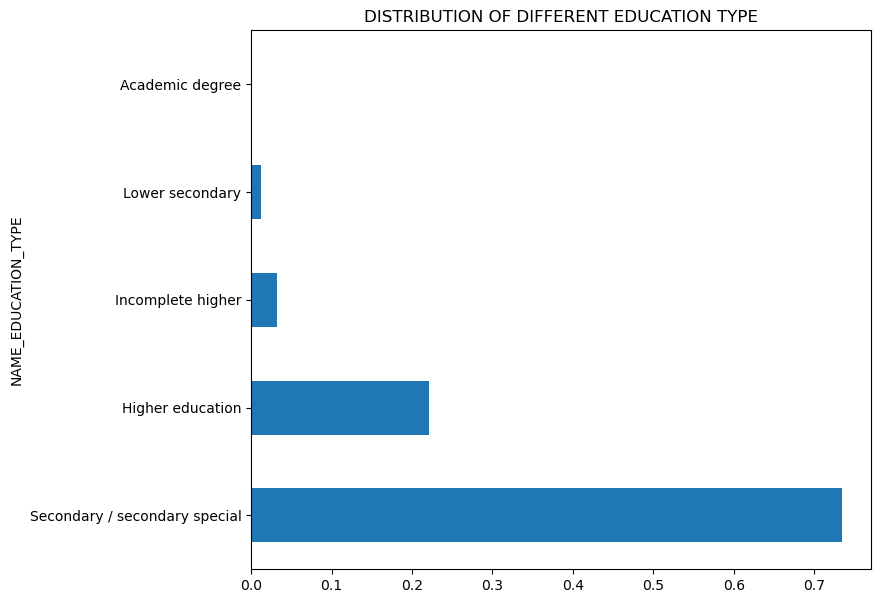

In [222]:
#plot the bar chart of education categories
plt.figure(figsize=(8,7))
df["NAME_EDUCATION_TYPE"].value_counts(normalize = True).plot.barh()
plt.title("DISTRIBUTION OF DIFFERENT EDUCATION TYPE")
plt.show()

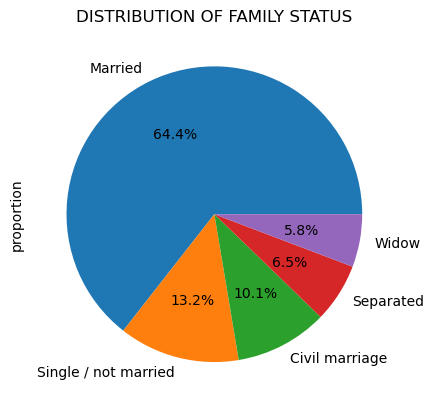

In [178]:
#plot the pie chart of family status categories
df["NAME_FAMILY_STATUS"].value_counts(normalize = True).plot.pie(autopct = "%0.1f%%")
plt.title("DISTRIBUTION OF FAMILY STATUS")
plt.show()

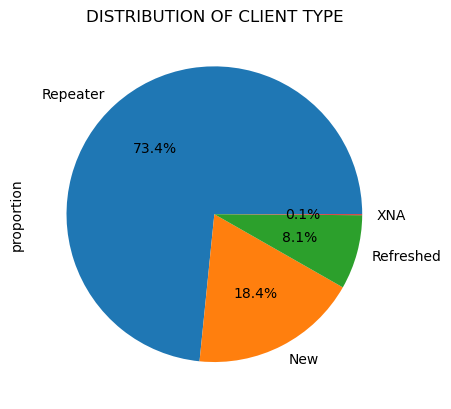

In [215]:
#Uni-variate analysis for CLIENT_TYPE category
df["NAME_CLIENT_TYPE"].value_counts(normalize = True).plot.pie(autopct = "%0.1f%%")
plt.title("DISTRIBUTION OF CLIENT TYPE")
plt.show()


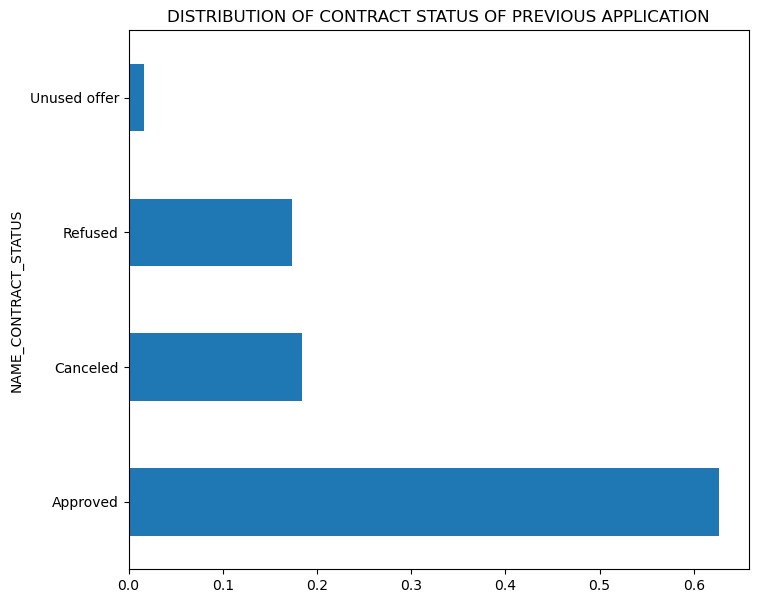

In [274]:
#plot the bar chart of contract status categories
plt.figure(figsize=(8,7))
df["NAME_CONTRACT_STATUS"].value_counts(normalize = True).plot.barh()
plt.title("DISTRIBUTION OF CONTRACT STATUS OF PREVIOUS APPLICATION")
plt.show()

## Data Analysis - Bivariate

In [163]:
#Bi-variate analysis for CONTRACT_TYPE and TARGET
df.groupby(["NAME_CONTRACT_TYPE_x","TARGET"])["TARGET"].count()/df.groupby(["NAME_CONTRACT_TYPE_x"])["TARGET"].count()*100

NAME_CONTRACT_TYPE_x  TARGET
Cash loans            0         91.085023
                      1          8.914977
Revolving loans       0         94.529300
                      1          5.470700
Name: TARGET, dtype: float64

In [164]:
#Bi-variate analysis for CODE_GENDER and TARGET
df.groupby(["CODE_GENDER","TARGET"])["TARGET"].count()/df.groupby(["CODE_GENDER"])["TARGET"].count()*100

CODE_GENDER  TARGET
F            0          92.374304
             1           7.625696
M            0          89.198856
             1          10.801144
XNA          0         100.000000
Name: TARGET, dtype: float64

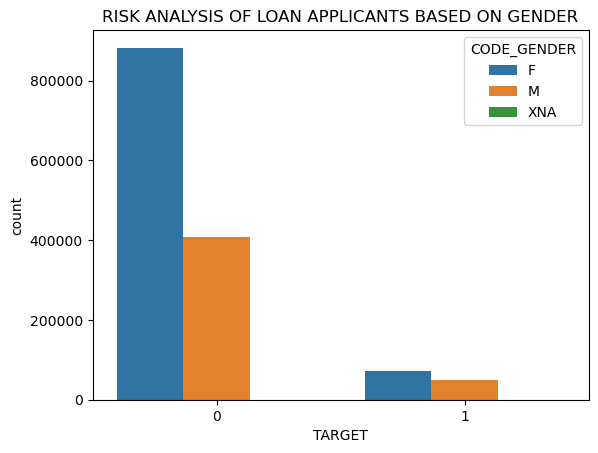

In [232]:
sns.countplot(x="TARGET",data=df,hue="CODE_GENDER")
plt.title("RISK ANALYSIS OF LOAN APPLICANTS BASED ON GENDER")
plt.show()

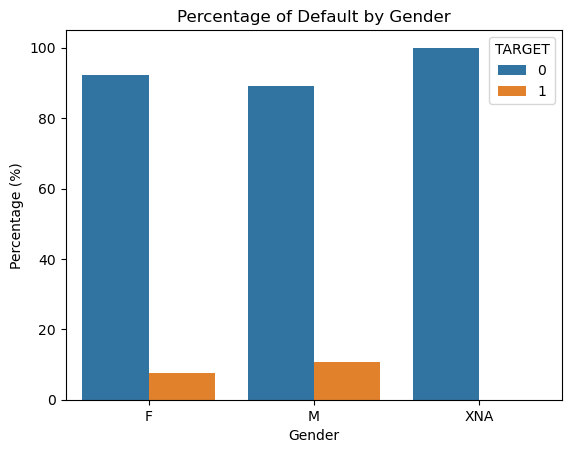

In [238]:
#Credit risk analysis based on Gender and default percentage
gender_target = (df.groupby("CODE_GENDER")["TARGET"]
                 .value_counts(normalize=True)
                 .rename("percentage")
                 .mul(100)
                 .reset_index())

sns.barplot(data=gender_target, x="CODE_GENDER", y="percentage", hue="TARGET")
plt.title("Percentage of Default by Gender")
plt.ylabel("Percentage (%)")
plt.xlabel("Gender")
plt.show()

In [241]:
#Bi-variate analysis for INCOME_TYPE and TARGET
df.groupby(["NAME_INCOME_TYPE","TARGET"])["TARGET"].count()/df.groupby(["NAME_INCOME_TYPE"])["TARGET"].count()*100

NAME_INCOME_TYPE      TARGET
Commercial associate  0          91.885990
                      1           8.114010
Maternity leave       1         100.000000
Pensioner             0          94.166204
                      1           5.833796
State servant         0          93.588494
                      1           6.411506
Student               0         100.000000
Unemployed            0          45.528455
                      1          54.471545
Working               0          89.755403
                      1          10.244597
Name: TARGET, dtype: float64

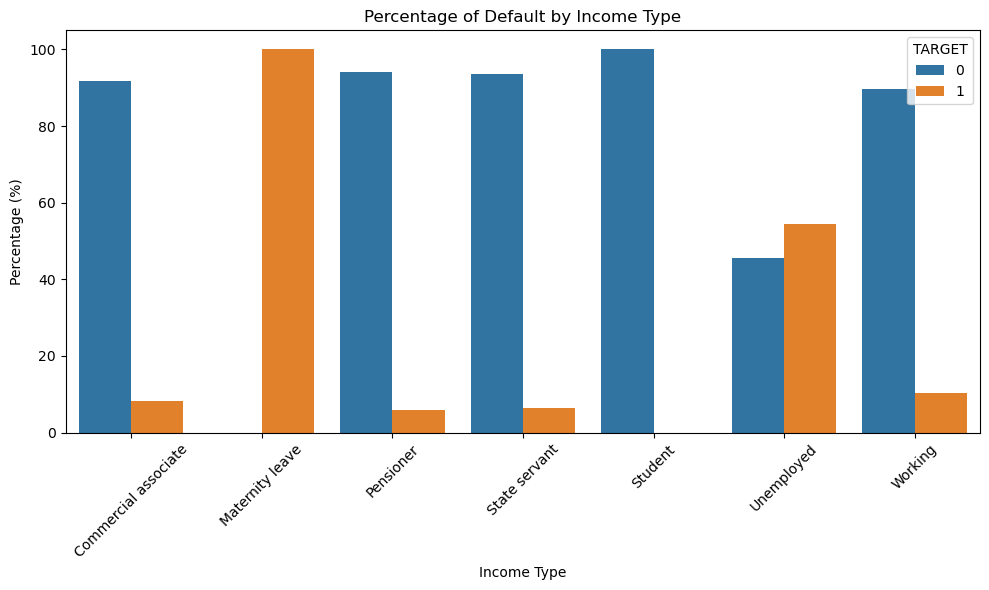

In [240]:
#Credit risk analysis based on Income type and default percentage
income_target = (
    df.groupby("NAME_INCOME_TYPE")["TARGET"]
    .value_counts(normalize=True)
    .rename("percentage")
    .mul(100)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=income_target, x="NAME_INCOME_TYPE", y="percentage", hue="TARGET")
plt.title("Percentage of Default by Income Type")
plt.ylabel("Percentage (%)")
plt.xlabel("Income Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [168]:
#Bi-variate analysis for EDUCATION_TYPE and TARGET
df.groupby(["NAME_EDUCATION_TYPE","TARGET"])["TARGET"].count()/df.groupby(["NAME_EDUCATION_TYPE"])["TARGET"].count()*100

NAME_EDUCATION_TYPE            TARGET
Academic degree                0         98.272884
                               1          1.727116
Higher education               0         93.951318
                               1          6.048682
Incomplete higher              0         91.015461
                               1          8.984539
Lower secondary                0         89.122582
                               1         10.877418
Secondary / secondary special  0         90.606242
                               1          9.393758
Name: TARGET, dtype: float64

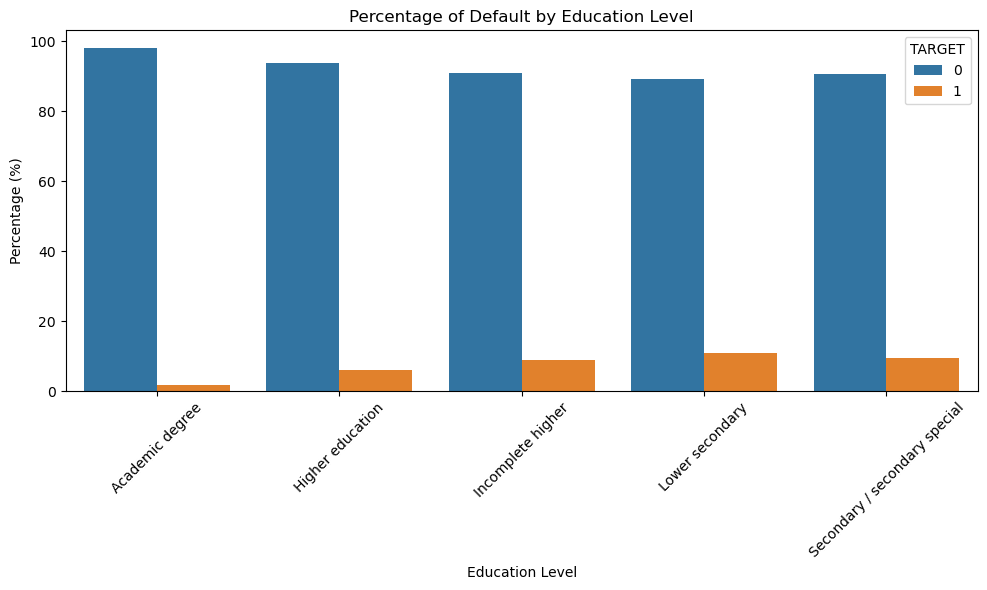

In [242]:
edu_target = (
    df.groupby("NAME_EDUCATION_TYPE")["TARGET"]
    .value_counts(normalize=True)
    .rename("percentage")
    .mul(100)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=edu_target, x="NAME_EDUCATION_TYPE", y="percentage", hue="TARGET")
plt.title("Percentage of Default by Education Level")
plt.ylabel("Percentage (%)")
plt.xlabel("Education Level")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [169]:
#Bi-variate analysis for CFAMILY_STATUS and TARGET
df.groupby(["NAME_FAMILY_STATUS","TARGET"])["TARGET"].count()/df.groupby(["NAME_FAMILY_STATUS"])["TARGET"].count()*100

NAME_FAMILY_STATUS    TARGET
Civil marriage        0         89.686149
                      1         10.313851
Married               0         91.657683
                      1          8.342317
Separated             0         91.513937
                      1          8.486063
Single / not married  0         89.841260
                      1         10.158740
Widow                 0         94.008991
                      1          5.991009
Name: TARGET, dtype: float64

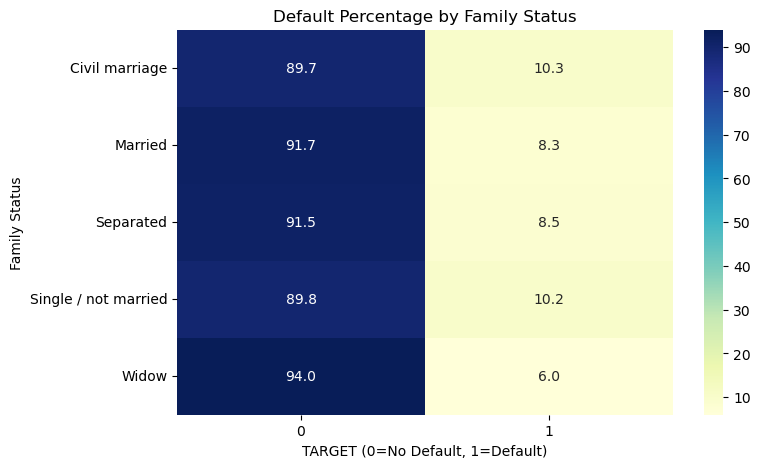

In [244]:
ct = pd.crosstab(df["NAME_FAMILY_STATUS"], df["TARGET"], normalize='index') * 100

plt.figure(figsize=(8, 5))
sns.heatmap(ct, annot=True, cmap="YlGnBu", fmt=".1f")
plt.title("Default Percentage by Family Status")
plt.xlabel("TARGET (0=No Default, 1=Default)")
plt.ylabel("Family Status")
plt.show()


In [261]:
#Bi-variate analysis for CLIENT_TYPE and TARGET
df.groupby(["NAME_CLIENT_TYPE","TARGET"])["TARGET"].count()/df.groupby(["NAME_CLIENT_TYPE"])["TARGET"].count()*100

NAME_CLIENT_TYPE  TARGET
New               0         91.005240
                  1          8.994760
Refreshed         0         92.663743
                  1          7.336257
Repeater          0         91.285384
                  1          8.714616
XNA               0         90.084251
                  1          9.915749
Name: TARGET, dtype: float64

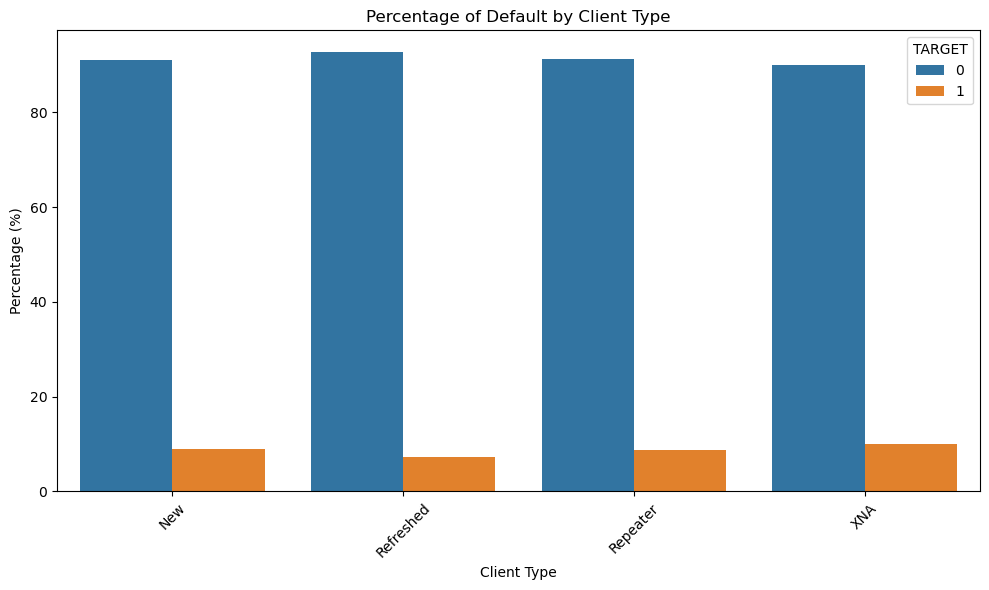

In [260]:
edu_target = (
    df.groupby("NAME_CLIENT_TYPE")["TARGET"]
    .value_counts(normalize=True)
    .rename("percentage")
    .mul(100)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=edu_target, x="NAME_CLIENT_TYPE", y="percentage", hue="TARGET")
plt.title("Percentage of Default by Client Type")
plt.ylabel("Percentage (%)")
plt.xlabel("Client Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [275]:
#Bi-variate analysis for CONTRACT_STATUS and TARGET
df.groupby(["NAME_CONTRACT_STATUS","TARGET"])["TARGET"].count()/df.groupby(["NAME_CONTRACT_STATUS"])["TARGET"].count()*100

NAME_CONTRACT_STATUS  TARGET
Approved              0         92.411345
                      1          7.588655
Canceled              0         90.826431
                      1          9.173569
Refused               0         88.003586
                      1         11.996414
Unused offer          0         91.748276
                      1          8.251724
Name: TARGET, dtype: float64

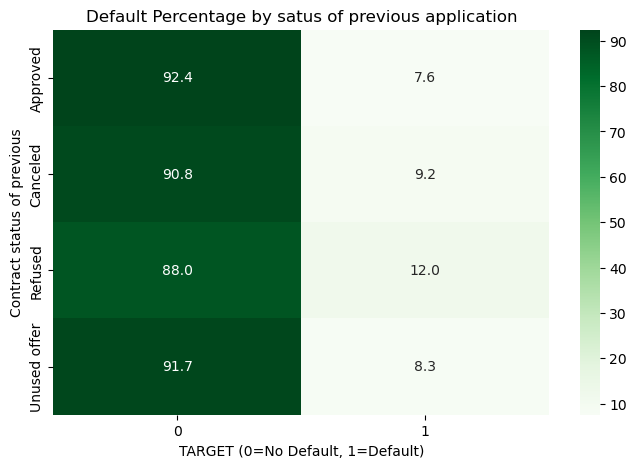

In [279]:
ct2 = pd.crosstab(df["NAME_CONTRACT_STATUS"], df["TARGET"], normalize='index') * 100

plt.figure(figsize=(8, 5))
sns.heatmap(ct2, annot=True, cmap="Greens", fmt=".1f")
plt.title("Default Percentage by satus of previous application")
plt.xlabel("TARGET (0=No Default, 1=Default)")
plt.ylabel("Contract status of previous")
plt.show()

In [246]:
df.AMT_INCOME_TOTAL.min()

25650.0

In [247]:
df.AMT_INCOME_TOTAL.max()

117000000.0

<Axes: xlabel='CODE_GENDER', ylabel='AMT_INCOME_TOTAL'>

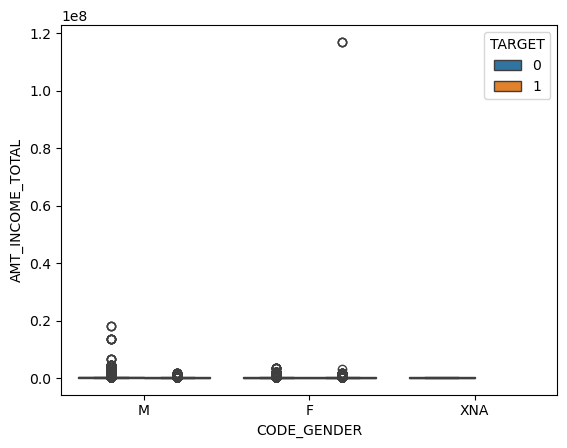

In [263]:
sns.boxplot(x='TARGET', y='AMT_INCOME_TOTAL', hue='TARGET', data=df)

In [266]:
q99 = df['AMT_INCOME_TOTAL'].quantile(0.99)
filtered_df = df[df['AMT_INCOME_TOTAL'] < q99]

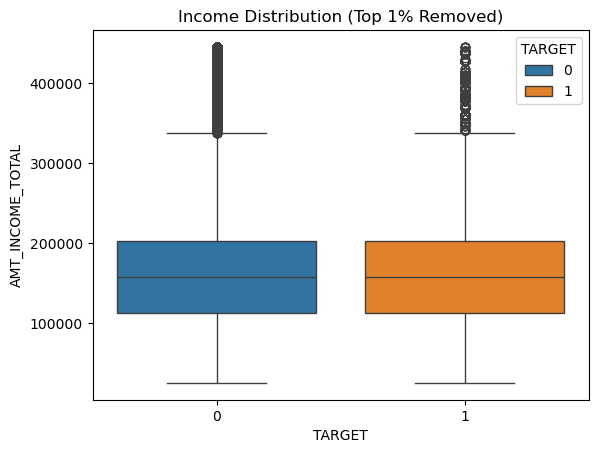

In [267]:
sns.boxplot(x='TARGET', y='AMT_INCOME_TOTAL', hue='TARGET', data=filtered_df)
plt.title('Income Distribution (Top 1% Removed)')
plt.show()

## Data Analysis - Multi-variate

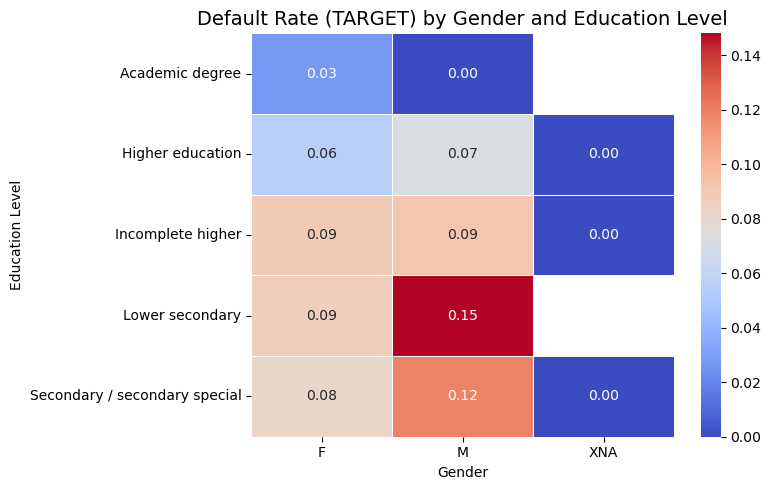

In [255]:
#Multi-variate analysis for TARGET, GENDER and EDUCATION_TYPE
pivot_table = df.pivot_table(
    values='TARGET',
    index='NAME_EDUCATION_TYPE',   # rows
    columns='CODE_GENDER',         # columns
    aggfunc='mean'                 # average default rate
)

plt.figure(figsize=(8, 5))
sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Default Rate (TARGET) by Gender and Education Level", fontsize=14)
plt.xlabel("Gender")
plt.ylabel("Education Level")
plt.tight_layout()
plt.show()

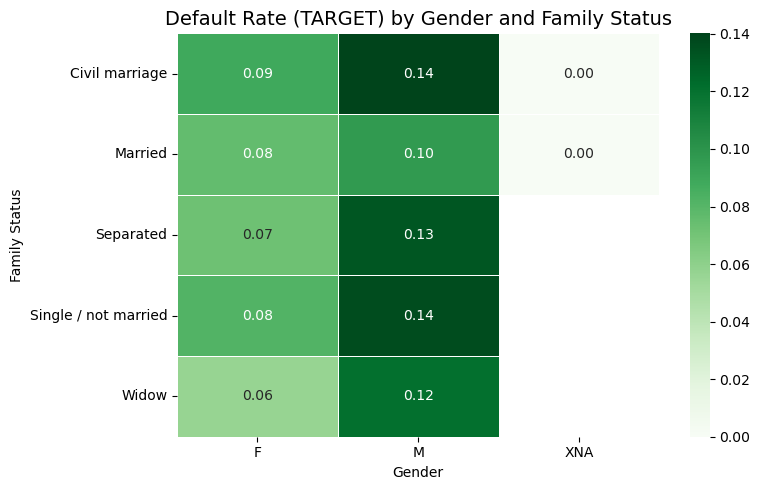

In [292]:
#Multi-variate analysis for TARGET, GENDER and FAMILY_STATUS
pivot_table2 = df.pivot_table(
    values='TARGET',
    index='NAME_FAMILY_STATUS',   # rows
    columns='CODE_GENDER',        # columns
    aggfunc='mean'                # average default rate
)

plt.figure(figsize=(8, 5))
sns.heatmap(
    pivot_table2,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    linewidths=0.5
)

plt.title("Default Rate (TARGET) by Gender and Family Status", fontsize=14)
plt.xlabel("Gender")
plt.ylabel("Family Status")
plt.tight_layout()
plt.show()

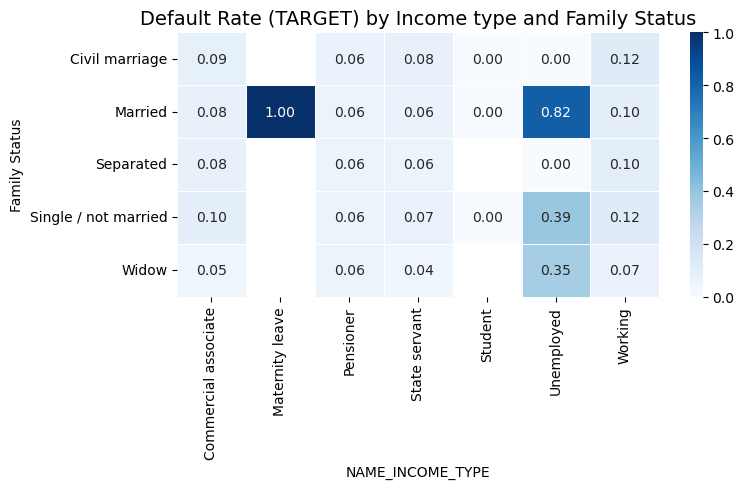

In [291]:
#Multi-variate analysis for TARGET, FAMILY_STATUS and INCOME_TYPE
pivot_table3 = df.pivot_table(
    values='TARGET',
    index='NAME_FAMILY_STATUS',   
    columns='NAME_INCOME_TYPE',        
    aggfunc='mean'              
)

plt.figure(figsize=(8, 5))
sns.heatmap(
    pivot_table3,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Default Rate (TARGET) by Income type and Family Status", fontsize=14)
plt.xlabel("NAME_INCOME_TYPE")
plt.ylabel("Family Status")
plt.tight_layout()
plt.show()

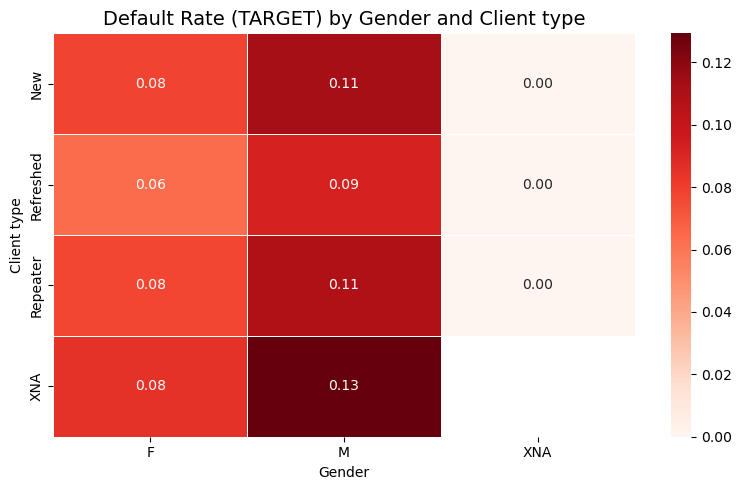

In [295]:
#Multi-variate analysis for TARGET, CLIENT_TYPE and GENDER
pivot_table4 = df.pivot_table(
    values='TARGET',
    index='NAME_CLIENT_TYPE',   # rows
    columns='CODE_GENDER',        # columns
    aggfunc='mean'                # average default rate
)

plt.figure(figsize=(8, 5))
sns.heatmap(
    pivot_table4,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    linewidths=0.5
)

plt.title("Default Rate (TARGET) by Gender and Client type", fontsize=14)
plt.xlabel("Gender")
plt.ylabel("Client type")
plt.tight_layout()
plt.show()

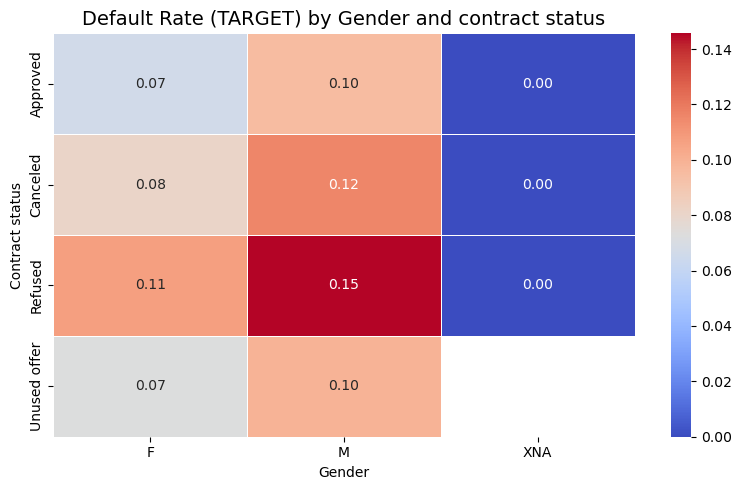

In [288]:
#Multi-variate analysis for TARGET, CONTRACT_STATUS and GENDER
pivot_table5 = df.pivot_table(
    values='TARGET',
    index='NAME_CONTRACT_STATUS',   # rows
    columns='CODE_GENDER',        # columns
    aggfunc='mean'                # average default rate
)

plt.figure(figsize=(8, 5))
sns.heatmap(
    pivot_table5,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Default Rate (TARGET) by Gender and contract status", fontsize=14)
plt.xlabel("Gender")
plt.ylabel("Contract status")
plt.tight_layout()
plt.show()